# Analyse NextBuy — Simon
## Objectif : identifier les best sellers et les profils d'achat healthy

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

print("Chargement des données...")
aisles = pd.read_csv('./datasets/aisles.csv')
departments = pd.read_csv('./datasets/departments.csv')
products = pd.read_csv('./datasets/products.csv')
orders = pd.read_csv('./datasets/orders.csv', nrows=100_000)
order_products = pd.read_csv('./datasets/order_products.csv', nrows=100_000) 

print("Fusion en cours...")
products_enriched = products.merge(aisles, on='aisle_id', how='left')
products_enriched = products_enriched.merge(departments, on='department_id', how='left')

orders_details = order_products.merge(orders, on='order_id', how='left')

df_master = orders_details.merge(products_enriched, on='product_id', how='left')

print("Fusion terminée !")
display(df_master.head())
print(f"Dimensions du dataset final : {df_master.shape}")

Chargement des données...
Fusion en cours...
Fusion terminée !


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,Organic Egg Whites,86.0,16.0,eggs,dairy eggs
1,2,28985.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,Michigan Organic Kale,83.0,4.0,fresh vegetables,produce
2,2,9327.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,Garlic Powder,104.0,13.0,spices seasonings,pantry
3,2,45918.0,4.0,1.0,NaN,NaN,NaN,NaN,NaN,Coconut Butter,19.0,13.0,oils vinegars,pantry
4,2,30035.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,Natural Sweetener,17.0,13.0,baking ingredients,pantry


Dimensions du dataset final : (100000, 14)


In [75]:
print("Nombre de Valeurs nul dans le Dataset",df_master.isnull())
print("<=======================>")
print("Nombre de NaN dans chaque column:", df_master.isnull().sum())


Nombre de Valeurs nul dans le Dataset        order_id  product_id  add_to_cart_order  reordered  user_id  \
0         False       False              False      False     True   
1         False       False              False      False     True   
2         False       False              False      False     True   
3         False       False              False      False     True   
4         False       False              False      False     True   
...         ...         ...                ...        ...      ...   
99995     False       False              False      False     True   
99996     False       False              False      False     True   
99997     False       False              False      False     True   
99998     False       False              False      False     True   
99999     False       False              False      False     True   

       order_number  order_dow  order_hour_of_day  days_since_prior_order  \
0              True       True              

## 

## EASY	Find the best seller per  departement 

#### je dois d'abord trouver les product_id qui sont le plus commandés

In [76]:
ID_Product_Greater = df_master['product_id'].value_counts(dropna=False)
print(ID_Product_Greater)



product_id
24852.0    1459
13176.0    1216
21137.0     814
21903.0     719
47209.0     647
           ... 
30435.0       1
14873.0       1
13332.0       1
21205.0       1
45096.0       1
Name: count, Length: 16416, dtype: int64


### et les traduire avec leurs noms de produit et trouver la correlation  

In [77]:
dfProductaffilate= (df_master[["product_id", "product_name"]].head())
display(dfProductaffilate)

,product_id,product_name
0,33120.0,Organic Egg Whites
1,28985.0,Michigan Organic Kale
2,9327.0,Garlic Powder
3,45918.0,Coconut Butter
4,30035.0,Natural Sweetener


### On tchek le nombre d'achat, dans le tableau qu'on crée

In [78]:

ventes =(df_master.groupby(["department_id", "department", "product_id", "product_name"], as_index=False).size().rename(columns={"size": "nombres_Dachat"}))
ventes.head()

,department_id,department,product_id,product_name,nombres_Dachat
0,1.0,frozen,4.0,Smart Ones Classic Favorites Mini Rigatoni Wit...,1
1,1.0,frozen,12.0,Chocolate Fudge Layer Cake,1
2,1.0,frozen,30.0,"Three Cheese Ziti, Marinara with Meatballs",1
3,1.0,frozen,46.0,Raisin Cinnamon Bagels 5 count,2
4,1.0,frozen,100.0,Peanut Butter & Strawberry Jam Sandwich,1


In [79]:
df = pd.DataFrame(df_master)
df = df.set_index("department")
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle
department,,,,,,,,,,,,,
dairy eggs,2,33120.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,Organic Egg Whites,86.0,16.0,eggs
produce,2,28985.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,Michigan Organic Kale,83.0,4.0,fresh vegetables
pantry,2,9327.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,Garlic Powder,104.0,13.0,spices seasonings
pantry,2,45918.0,4.0,1.0,NaN,NaN,NaN,NaN,NaN,Coconut Butter,19.0,13.0,oils vinegars
pantry,2,30035.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,Natural Sweetener,17.0,13.0,baking ingredients


### 

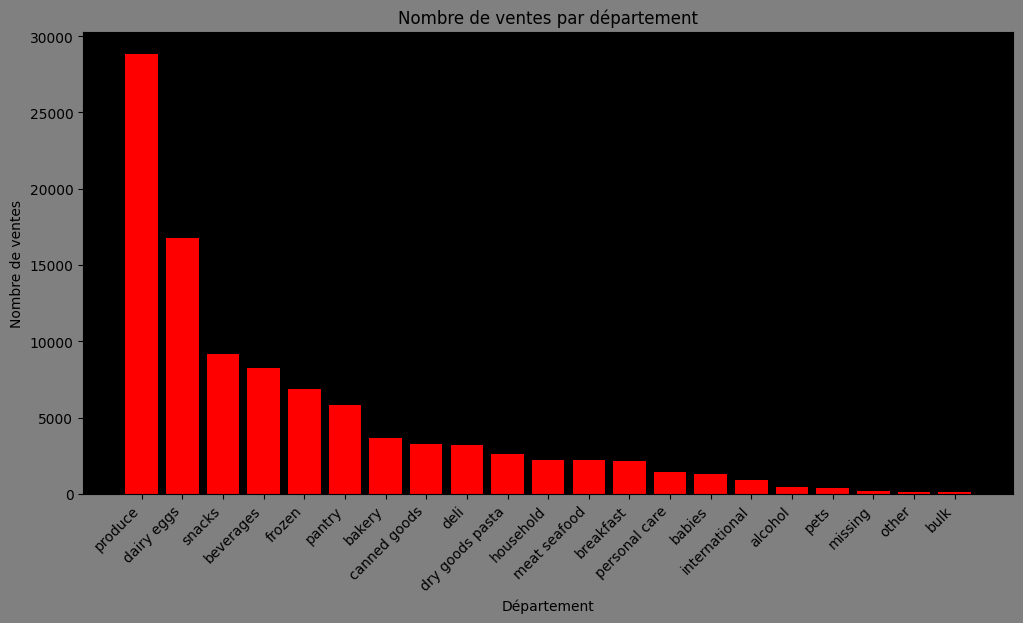

In [80]:
import matplotlib.pyplot as plt

# Compter le nombre de ventes par département
ventes_par_dept = df_master.groupby('department').size().sort_values(ascending=False)



plt.figure(figsize=(12, 6),facecolor='grey')
ax = plt.gca()  
ax.set_facecolor("black")
plt.bar(ventes_par_dept.index, ventes_par_dept.values, color='red')
plt.title('Nombre de ventes par département')
plt.xlabel('Département')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.show()

## Meilleur visualisation sur un Camembert

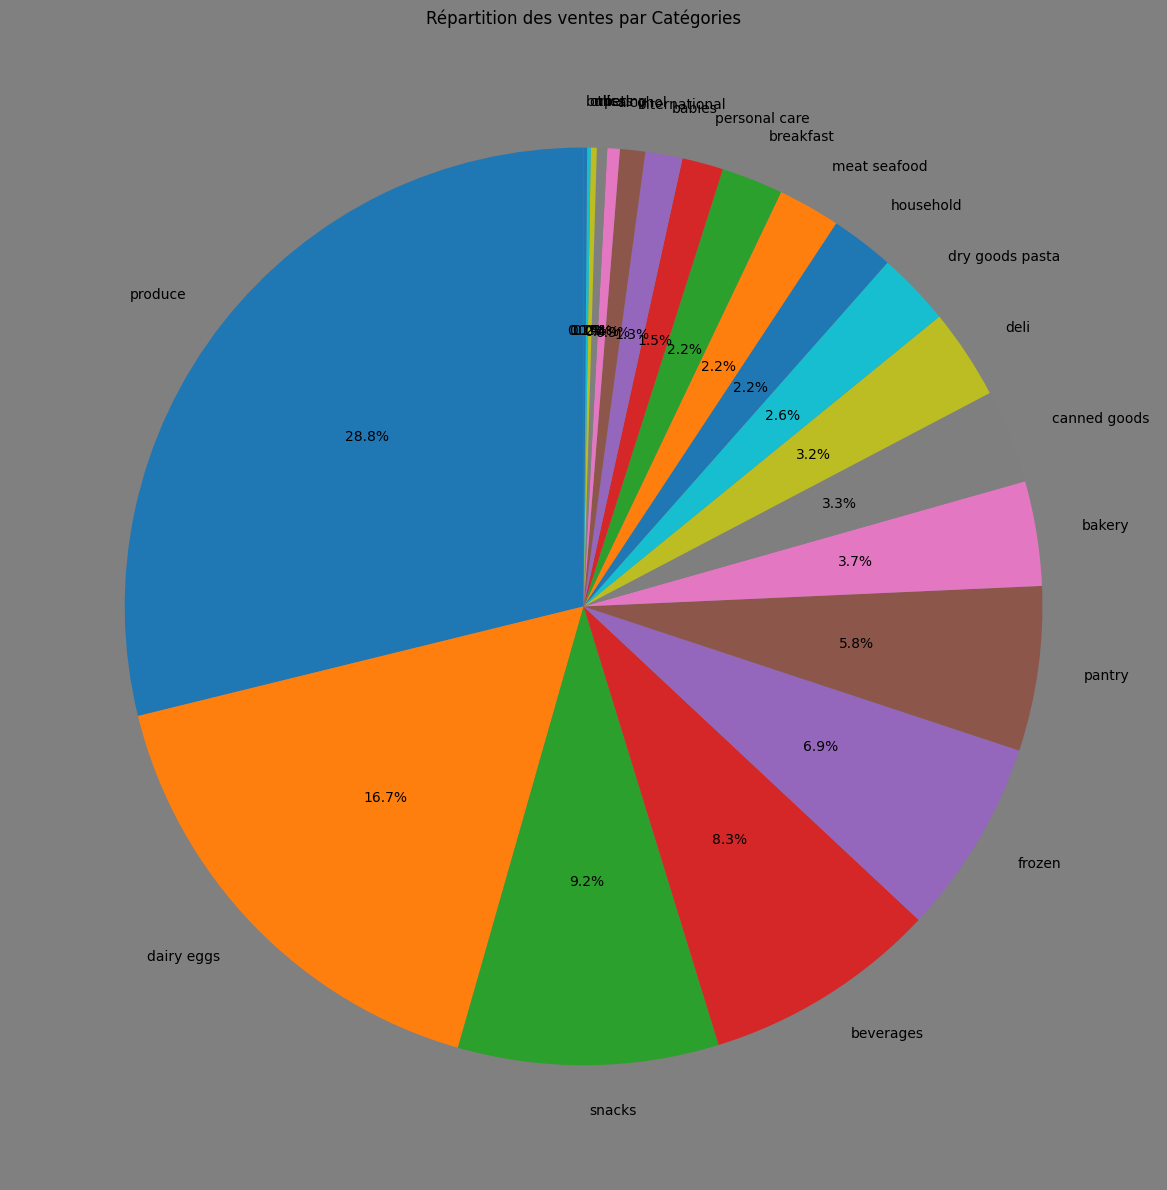

In [81]:

plt.figure(figsize=(12, 12),facecolor='grey')
plt.pie(
    ventes_par_dept.values,
    labels=ventes_par_dept.index,
    autopct='%1.1f%%',     
    startangle=90,           
)

plt.title('Répartition des ventes par Catégories')
plt.tight_layout()
plt.show()

### La data "Produce" est très grande car c'est les fruit et legumes , c'est donc des produits pérrisable et donc a haut rendement 


# HARD , Trouver les produits healthy , bon pour le corps , protéiné , low calories qui pourraient êtres recommendé pour les Client qui cherchent à perdre du Poids.
### Donc afficher un graphique qui donnerai le pourcentage de produit healthy par departement 

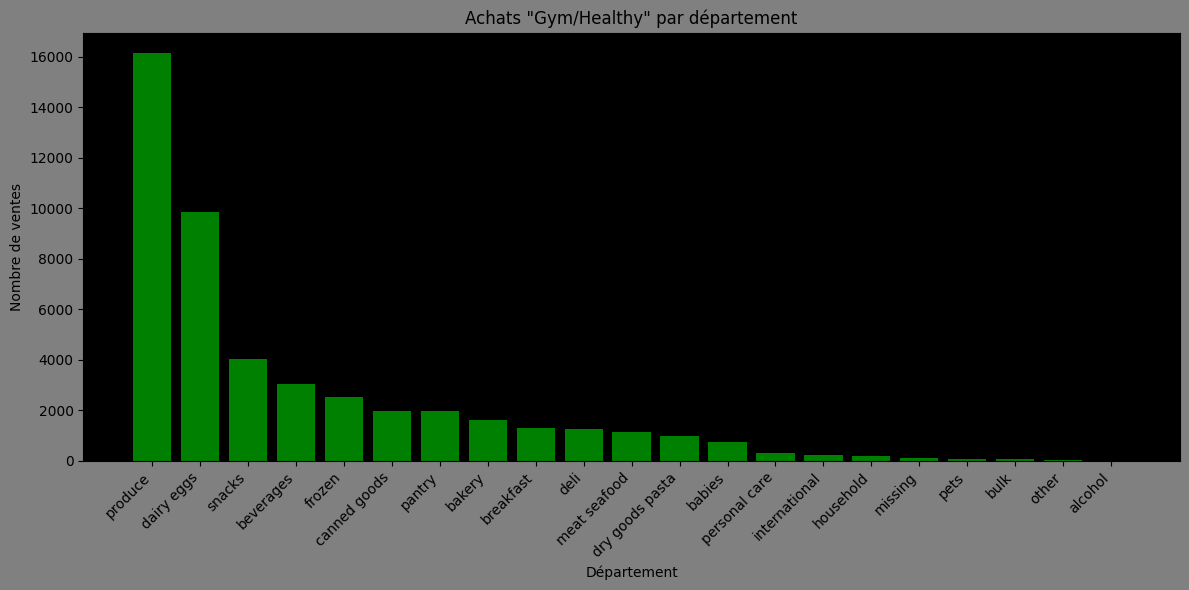

In [82]:
keywords_healthy = [
    # Protéines
    'protein', 'whey', 'casein', 'collagen', 'egg white', 'tuna', 
    'chicken breast', 'turkey', 'tofu', 'tempeh', 'edamame',

    # Healthy / Clean eating
    'organic', 'natural', 'whole grain', 'multigrain', 'whole wheat',
    'sugar free', 'sugar-free', 'fat free', 'fat-free', 'low fat',
    'low-fat', 'low calorie', 'low carb', 'low sodium', 'light',
    'reduced', 'zero', 'no added sugar', 'unsweetened',

    # Superfoods / Fitness
    'kale', 'spinach', 'quinoa', 'chia', 'flax', 'hemp',
    'acai', 'spirulina', 'matcha', 'turmeric', 'ginger',
    'almond', 'cashew', 'walnut', 'oat', 'granola',

    # Régimes
    'vegan', 'gluten free', 'gluten-free', 'dairy free', 'dairy-free',
    'paleo', 'keto', 'non-gmo', 'non gmo',

    # Boissons sport
    'electrolyte', 'energy', 'bcaa', 'creatine', 'pre-workout',
    'coconut water', 'green tea', 'kombucha',

    # Laitage healthy
    'greek yogurt', 'skyr', 'cottage', 'almond milk', 'oat milk',
    'soy milk', 'plant based', 'plant-based'
]
pattern_healthy = '|'.join(keywords_healthy)                    
healthy_df = df_master[df_master['product_name'].str.lower().str.contains(pattern_healthy, na=False)]

# Compter les ventes de ces produits par category(departement)
ventes_gym = healthy_df.groupby('department').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6),facecolor='grey')
ax = plt.gca()  
ax.set_facecolor("black")
plt.bar(ventes_gym.index, ventes_gym.values, color='green')
plt.title('Achats "Gym/Healthy" par département')
plt.xlabel('Département')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## On retrouve la même statistique que le graph de nombre de vente pas departement car c'est evidement coorélée.
### je vais essayer de creuser un peu plus et diviser la range dfe filtre

# Start of Useless stats


# Produit Protéiné par Catégories

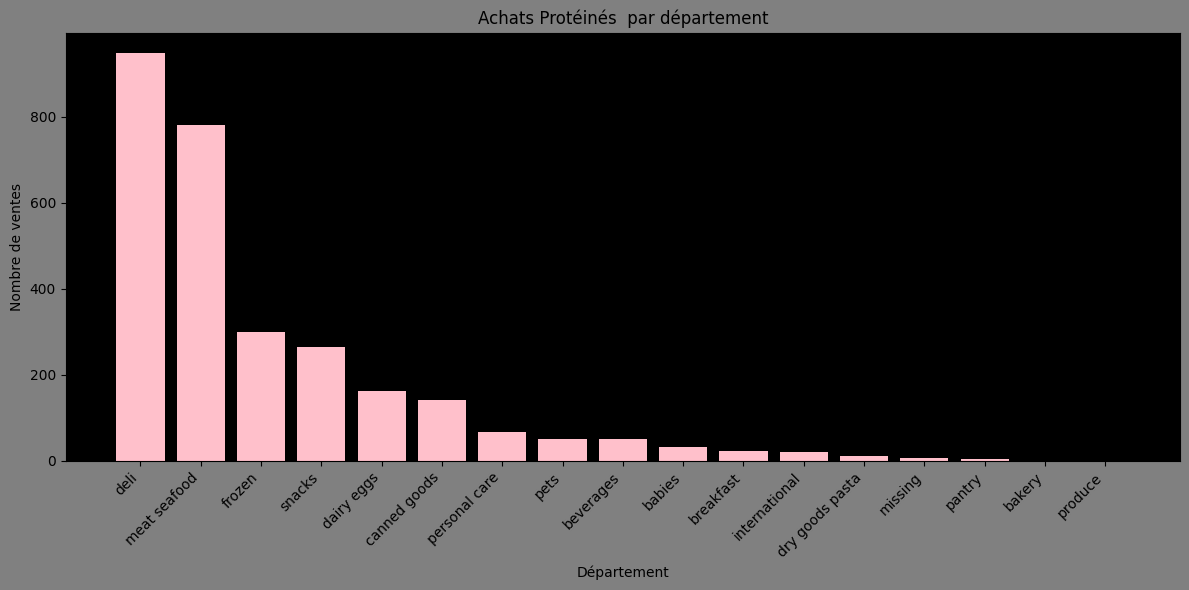

In [83]:
keywords = [
    # Protéines
    'protein', 'whey', 'casein', 'collagen', 'egg white', 'tuna', 
    'chicken breast', 'turkey', 'tofu', 'tempeh', 'edamame']
pattern = '|'.join(keywords) 

gym_df = df_master[df_master['product_name'].str.lower().str.contains(pattern, na=False)]             

# Compter les ventes de ces produits par category(departement)
ventes_gym = gym_df.groupby('department').size().sort_values(ascending=False)
plt.figure(figsize=(12, 6),facecolor='grey')
ax = plt.gca()  
ax.set_facecolor("black")

plt.bar(ventes_gym.index, ventes_gym.values, color='pink')
plt.title('Achats Protéinés  par département')
plt.xlabel('Département')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### "Deli" veut dire "Delicatessen food" donc en gros de la nourriture de haute qualité , avec des produits Etiquement correcte a base de viandes donc protéiné qui sont déjà cuisiné et prêt à manger d'où la première place. 

# Produuit healthy ou clean par departement 

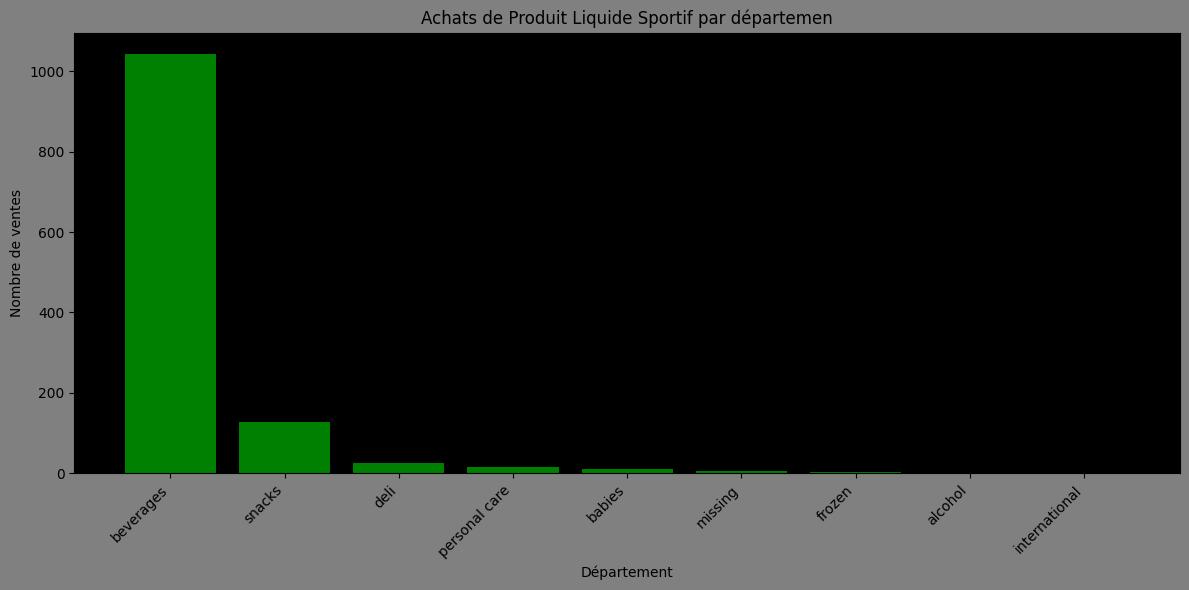

In [84]:
keywords = [
    'electrolyte', 'energy', 'bcaa', 'creatine', 'pre-workout',
    'coconut water', 'green tea', 'kombucha']
pattern = '|'.join(keywords) 

gym_df = df_master[df_master['product_name'].str.lower().str.contains(pattern, na=False)]

# Compter les ventes de ces produits par category(departement)
ventes_gym = gym_df.groupby('department').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6),facecolor='grey')
ax = plt.gca()  
ax.set_facecolor("black")
plt.bar(ventes_gym.index, ventes_gym.values, color='green')
plt.title('Achats de Produit Liquide Sportif par départemen')
plt.xlabel('Département')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Donc c'est logique que les Fruits et Legumes soient en premiers 

## Laitage healthy

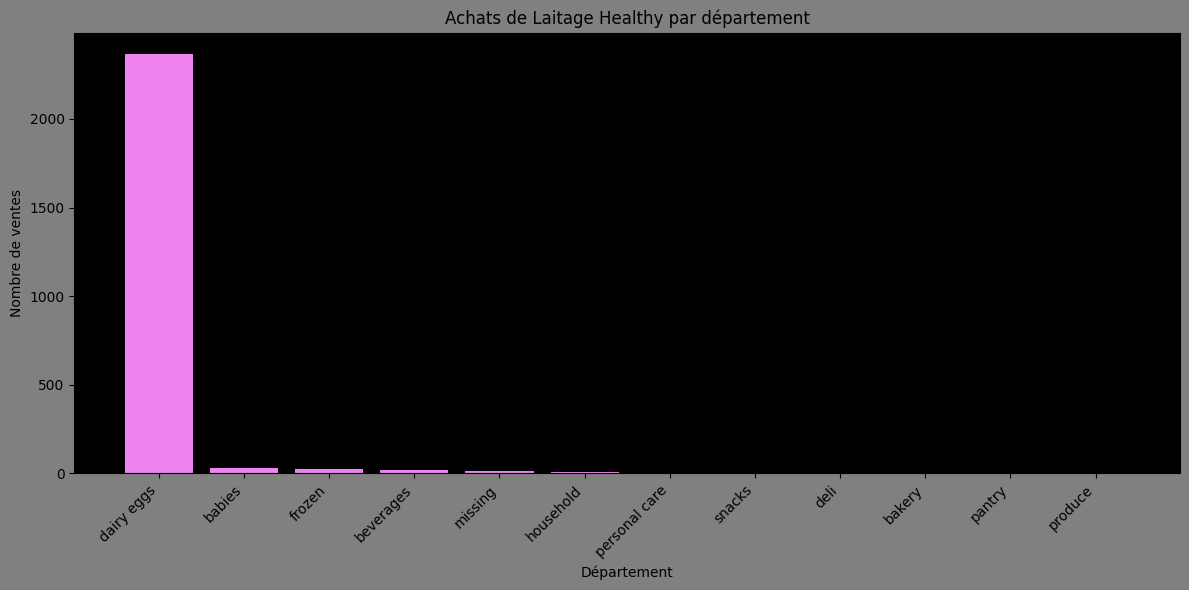

In [85]:
keywords = [
    'greek yogurt', 'skyr', 'cottage', 'almond milk', 'oat milk',
    'soy milk', 'plant based', 'plant-based']
pattern = '|'.join(keywords) 

gym_df = df_master[df_master['product_name'].str.lower().str.contains(pattern, na=False)]

# Compter les ventes de ces produits par category(departement)
ventes_gym = gym_df.groupby('department').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6),facecolor='grey')
ax = plt.gca()  
ax.set_facecolor("black")
plt.bar(ventes_gym.index, ventes_gym.values, color='violet')
plt.title('Achats de Laitage Healthy par département')
plt.xlabel('Département')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# End of Useless stats

# Quel % des achats totaux sont healthy ? 

### Je vais d'abord filtrer et cibler les produits non healthy avant de les comparées avec les produits healthy 

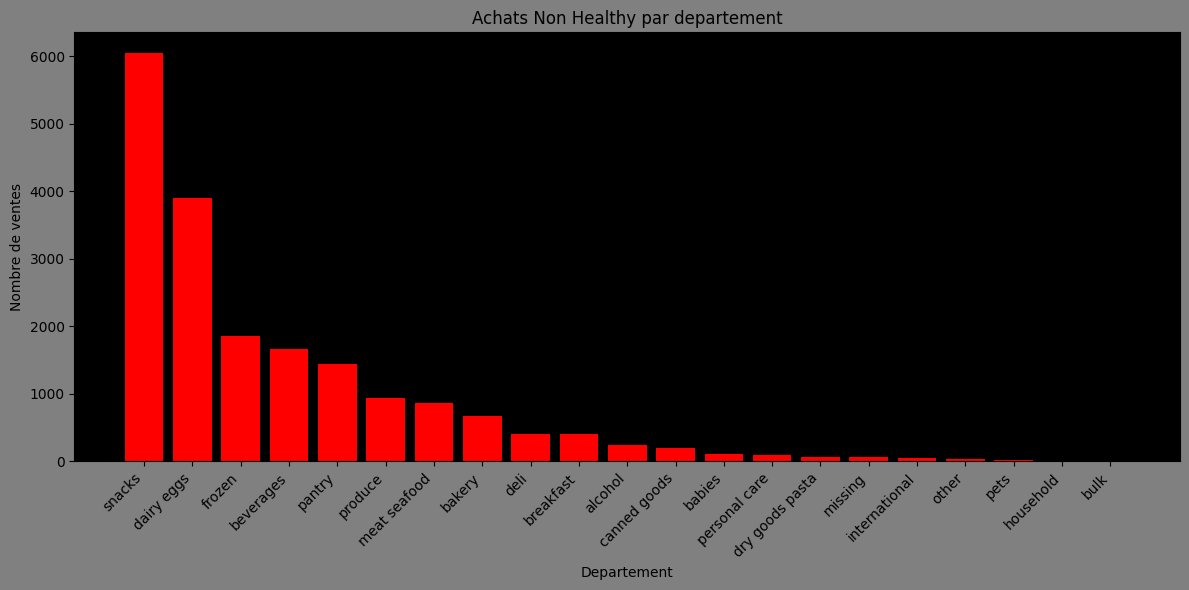

In [86]:
unhealthy_keywords = [

    'chips', 'crackers', 'popcorn', 'pretzel', 'nachos',
    'hot dog', 'bacon', 'sausage', 'pepperoni', 'salami',

    
    'candy', 'chocolate', 'cookie', 'brownie', 'cake',
    'donut', 'muffin', 'waffle', 'pancake', 'syrup',
    'frosting', 'fudge', 'caramel', 'marshmallow', 'gummy',
    'lollipop', 'licorice', 'toffee', 'nougat',

 
    'soda', 'cola', 'sprite', 'fanta', 'energy drink',
    'juice drink', 'lemonade', 'sweetened', 'flavored drink',


    'cream cheese', 'heavy cream', 'whipped cream', 'butter',
    'full fat', 'whole milk', 'mayo', 'mayonnaise',

 
    'fried', 'deep fried', 'crispy', 'crunchy snack',
    'instant', 'processed', 'frozen pizza', 'mac and cheese',


    'beer', 'wine', 'vodka', 'whiskey', 'rum', 'tequila',
    'ale', 'lager', 'cider', 'cocktail', 'hard seltzer',

    'salted', 'extra salt', 'pickled', 'jerky',
]

pattern_unhealthy = '|'.join(unhealthy_keywords)         
unhealthy_df = df_master[df_master['product_name'].str.lower().str.contains(pattern_unhealthy, na=False)]  

ventes_unhealthy = unhealthy_df.groupby('department').size().sort_values(ascending=False)  

plt.figure(figsize=(12, 6), facecolor='grey')
ax = plt.gca()
ax.set_facecolor("black")
plt.bar(ventes_unhealthy.index, ventes_unhealthy.values, color='red')
plt.title('Achats Non Healthy par departement')
plt.xlabel('Departement')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Nous retrouvons bien les snack en première Place

# Produit Healthy vs Produit Non-Healthy

# Pour comparer les deux 

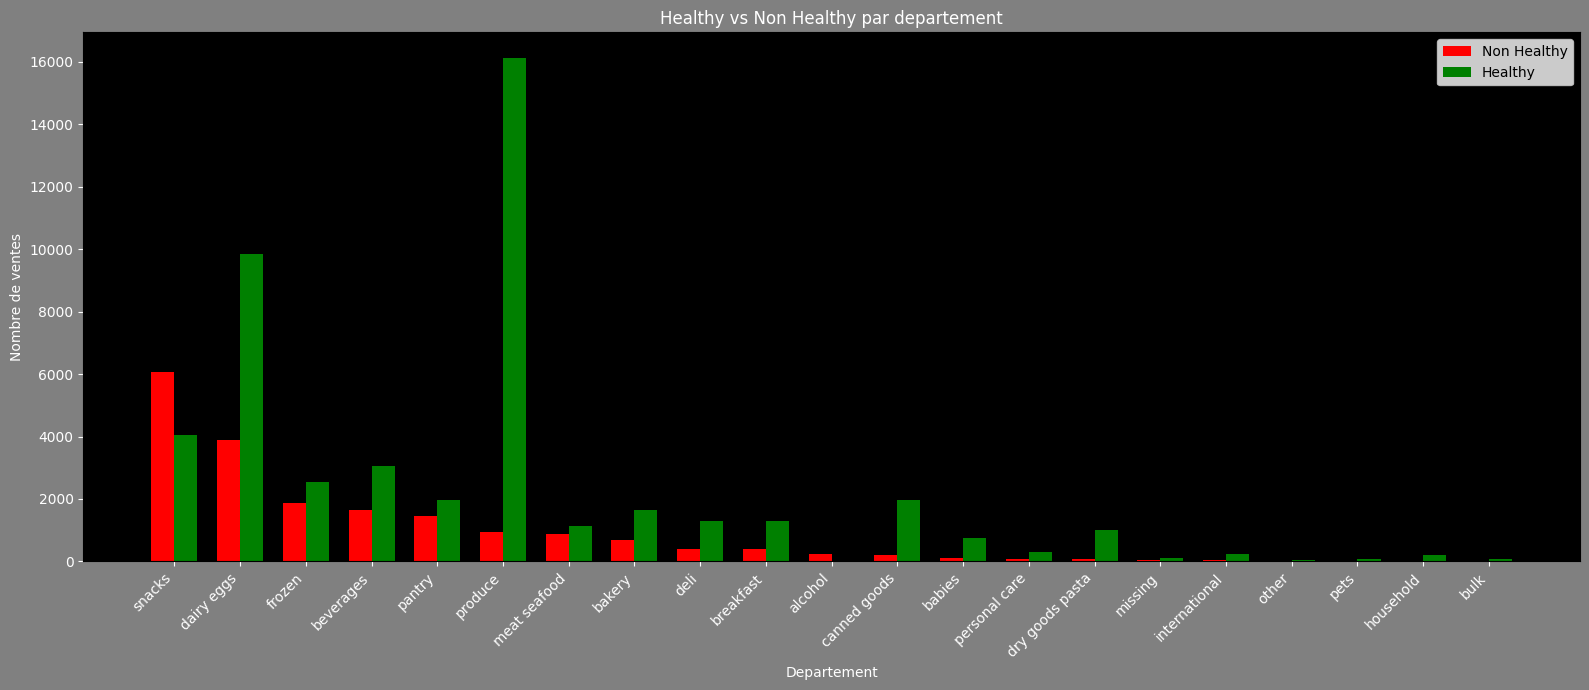

In [87]:
import numpy as np

ventes_healthy = healthy_df.groupby('department').size()
ventes_unhealthy = unhealthy_df.groupby('department').size()
#reindex force les deux a avoir le meme departement dans le meme ordre pour qu'ils sooient tous a coté de leurs homonyme  
all_depts = ventes_unhealthy.sort_values(ascending=False).index 
healthy_aligned = ventes_healthy.reindex(all_depts, fill_value=0)
unhealthy_aligned = ventes_unhealthy.reindex(all_depts, fill_value=0)
#remplace les noms des departemetn par des chiffres sinon on aurait pas pu les mettre, 
x = np.arange(len(all_depts))
width = 0.35

plt.figure(figsize=(16, 7), facecolor='grey')
ax = plt.gca()
ax.set_facecolor('black')
#placements des bar espacer pour pas qu'ils se chevauchent 
plt.bar(x - width/2, unhealthy_aligned.values, width=width, color='red', label='Non Healthy')
plt.bar(x + width/2, healthy_aligned.values, width=width, color='green', label='Healthy')

plt.xticks(x, all_depts, rotation=45, ha='right', color='white')#xticks remet les noms des departemetns sur l axe X a la fin 
plt.title('Healthy vs Non Healthy par departement', color='white')
plt.xlabel('Departement', color='white')
plt.ylabel('Nombre de ventes', color='white')
plt.tick_params(colors='white')
plt.legend()
plt.tight_layout()
plt.show()

### on remarque donc que les clients sont donc assez Healthy et responsable , ce ne sont suremment pas des Américains 

# Creation du model 
### Implementatio du Is Healthy oui ou non 

In [160]:
df_master['is_healthy'] =  df_master['product_name'].str.lower().str.contains(pattern_healthy, na=False).astype(int)#astype convertit les true en 1 etc
df_master[['product_name', 'is_healthy']].head(100)

df_master['is_healthy'].value_counts()

is_healthy
0    52310
1    47690
Name: count, dtype: int64

# TF IDF

In [159]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=500)# cree un outil qui va transfomer du texte en chiffres en gardant les 500 mots les plus importants
X = vectorizer.fit_transform(df_master['product_name'].fillna(''))#transforme chaque nom de produit en vecteur de chiffres 
y = df_master['is_healthy']#la reponse attendu - O ou 1 , heatlhy pas healthy 
print(X.shape)

(100000, 500)


### en gros on transfomrme producte name en chiffre pour que le model puisse les regarder eet les manipuler ; 'Banane' = [0,8,7,2,0,3 jusqu'a 500 ]

In [158]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(396, 372) (99, 372)


### on separe les valeurs de testes en 2 , une que le model va apprendre = x,y_train donc 80% et l'autre 20%  les produit qu'on lui cache pour tester sans triche 

# Premier Model  avec LogisticRegression

In [157]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

print("Logistic Regressin accuracy:", accuracy_score(y_test, y_pred1))

Logistic Regressin accuracy: 0.6868686868686869


# Deuxieme model avec RandomForeste

In [156]:
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print("Random Forest accuracy:", accuracy_score(y_test, y_pred2))

Random Forest accuracy: 0.6767676767676768


## Go tester avec un autre model 
### KNN 

In [168]:
from sklearn.neighbors import KNeighborsClassifier
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

model3 = KNeighborsClassifier()
model3.fit(X_train_dense, y_train)
y_pred3 = model3.predict(X_test_dense)

print("Logistic Regressin accuracy:", accuracy_score(y_test, y_pred3))

Logistic Regressin accuracy: 0.6868686868686869


## Maintenant regardons ce que ca donne si on compare 

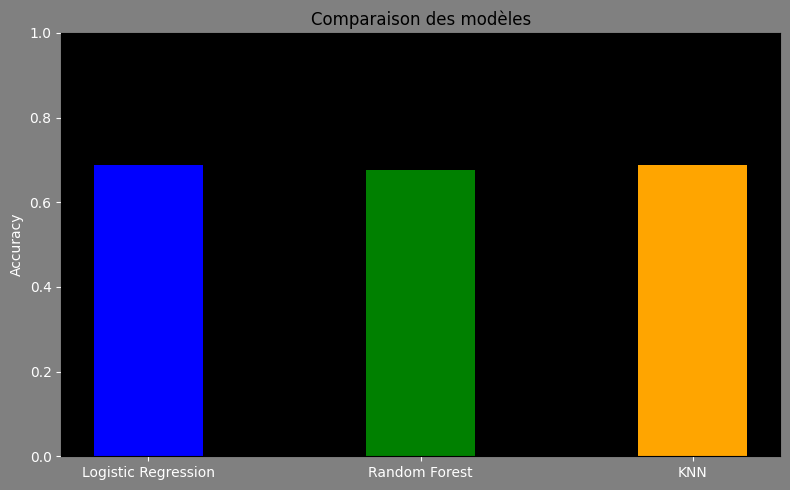

In [173]:
models = ['Logistic Regression', 'Random Forest', 'KNN']
scores = [accuracy_score(y_test, model1.predict(X_test)), 
          accuracy_score(y_test, model2.predict(X_test)),
          accuracy_score(y_test, model3.predict(X_test))]

plt.figure(figsize=(8, 5), facecolor='grey')
ax = plt.gca()
ax.set_facecolor('black')
plt.bar(models, scores, color=['blue', 'green', 'orange'], width=0.4)
plt.title('Comparaison des modèles')
color=['blue', 'green', 'orange']
plt.ylabel('Accuracy', color='white')
plt.ylim(0.0, 1.0)#pour zoomer sur la difference entre les deuc model sinon le sbarres paraissnet identique 
plt.tick_params(colors='white')
plt.tight_layout()
plt.show()

# le modele predit si le produit , par son Producte Name est Healthy ou pas 

### Limites du modèle
### Le score d'accuracy élevé (~99%) s'explique par un phénomène appelé data leakage.

### La colonne `is_healthy` a été créée à partir de `pattern_healthy` — une liste de keywords.
### Le TF-IDF a ensuite vectorisé les mêmes noms de produits.

### Résultat : le modèle n'a pas vraiment "appris" à distinguer healthy vs unhealthy.
### Il a simplement mémorisé les mots de notre liste.

### Une approche plus robuste consisterait à labelliser les produits via une source externe
## (base nutritionnelle, API Open Food Facts) indépendante des features d'entrée.

In [95]:
import requests
response = requests.get("https://world.openfoodfacts.org/cgi/search.pl?search_terms=banana&json=1")
print(response.status_code)
data = response.json()
print(data.keys())
print(data["products"][0].keys())
product = data["products"][0]
print(product.get("product_name"))
print(product.get("nutriments"))
print(product.get("nutriscore_grade"))

200
dict_keys(['count', 'page', 'page_count', 'page_size', 'products', 'skip'])
dict_keys(['_id', '_keywords', 'added_countries_tags', 'additives_n', 'additives_original_tags', 'additives_tags', 'allergens', 'allergens_from_ingredients', 'allergens_from_user', 'allergens_hierarchy', 'allergens_lc', 'allergens_tags', 'amino_acids_prev_tags', 'amino_acids_tags', 'brands', 'brands_old', 'brands_tags', 'categories', 'categories_hierarchy', 'categories_lc', 'categories_old', 'categories_properties', 'categories_properties_tags', 'categories_tags', 'category_properties', 'checkers_tags', 'ciqual_food_name_tags', 'cities_tags', 'code', 'codes_tags', 'compared_to_category', 'complete', 'completeness', 'correctors_tags', 'countries', 'countries_hierarchy', 'countries_lc', 'countries_tags', 'created_t', 'creator', 'data_quality_bugs_tags', 'data_quality_completeness_tags', 'data_quality_dimensions', 'data_quality_errors_tags', 'data_quality_info_tags', 'data_quality_tags', 'data_quality_warnings

# Call API open food facts
## Creation d'une fonction qui interroge l'APi open food facts pour recuperer les infos nutritionnelles d'un produit. `FindMacros`
### - 'try/exept' pour gérer les erreurs si le produit n'est pas trouvé 
### - retourne le nutriscore et les nutriments
### - affichage dans un dataframe avec uniquement les macros utiles :
### Kcal, sucres, glucides , protéines, lipides


In [96]:
import requests
import pandas as pd
def FindMacros(product_name):
    try:
        url = f"https://world.openfoodfacts.org/cgi/search.pl?search_terms={product_name}&json=1"
        response = requests.get(url)
        print(response.status_code)
        print(response.text[:200])
        data = response.json()
        if len(data["products"]) == 0:
            return None, None
        product = data["products"][0]
        nutriscor = product.get("nutriscore_grade")
        nutriments = product.get("nutriments")
        return nutriscor, nutriments
    except Exception as e:
        print(e)
        return None , None

nutriscor, nutriments = FindMacros("Prince Gout Chocolat")
df = pd.DataFrame([nutriments])
df[["energy-kcal_100g", "sugars_100g", "carbohydrates_100g", "proteins_100g", "fat_100g"]]

200
{"count":52,"page":1,"page_count":50,"page_size":50,"products":[{"_id":"7622210449283","_keywords":["35","and","biscuit","breakfast","cake","charte","chocolat","cracker","distributor","fourre","gout",


,energy-kcal_100g,sugars_100g,carbohydrates_100g,proteins_100g,fat_100g
0,465,31.5,70,6.5,17.5


In [140]:
import requests
import pandas as pd
import time

def FindMacros(product_name):
    try:
        url = f"https://world.openfoodfacts.org/cgi/search.pl?search_terms={product_name}&json=1"
        response = requests.get(url, timeout=10)
        data = response.json()
        if len(data["products"]) == 0:
            return None, None
        product = data["products"][0]
        nutriscor = product.get("nutriscore_grade")
        nutriments = product.get("nutriments")
        return nutriscor, nutriments
    except Exception as e:
        return None, None

produce_df = df_master[df_master["department"] == "produce"]
alltest = produce_df['product_name'].value_counts(dropna=False).head(1000)
resultats = []

for produce in alltest.index:
    nutriscor, nutriments = FindMacros(produce)
    resultats.append({"product": produce, "nutriments": nutriments, "nutriscor": nutriscor})
    time.sleep(1)

print(f"{len(resultats)} produits récupérés")

994 produits récupérés


## afficher les resultats de la get requestes dans un tableau 

In [141]:
df_resultas = pd.DataFrame(resultats)
df_resultas

,product,nutriments,nutriscor
0,Banana,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",c
1,Bag of Organic Bananas,None,None
2,Organic Strawberries,"{'carbohydrates': 37.4, 'carbohydrates_100g': ...",d
3,Organic Baby Spinach,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",a
4,Organic Hass Avocado,None,a
...,...,...,...
989,Hot House Seedless Cucumbers,None,None
990,Baby Dill,"{'carbohydrates': 3.57, 'carbohydrates_100g': ...",d
991,Bacon Caesar Kit,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",a
992,Grapefruit,"{'carbohydrates': 8.9, 'carbohydrates_100g': 8...",c


## On affiche mieux les nutriments

In [142]:

df_macros = pd.json_normalize(df_resultas["nutriments"])
df_macros[["energy-kcal_100g", "sugars_100g", "carbohydrates_100g", "proteins_100g", "fat_100g"]]

,energy-kcal_100g,sugars_100g,carbohydrates_100g,proteins_100g,fat_100g
0,88.100000,9.3,14.30,3.90,1.7
1,NaN,NaN,NaN,NaN,NaN
2,158.000000,37.4,37.40,0.50,0.1
3,23.529412,0.0,3.53,2.35,0.0
4,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
989,NaN,NaN,NaN,NaN,NaN
990,0.000000,0.0,3.57,0.00,0.0
991,160.000000,1.0,29.00,4.00,14.0
992,43.000000,8.9,8.90,0.50,0.1


### On met mieux les noms de colones sur la gauche 

In [143]:
df_macros["product_name"] = df_resultas["product"]
gooddf_macro = df_macros[["product_name", "energy-kcal_100g", "sugars_100g", "carbohydrates_100g", "proteins_100g", "fat_100g"]].copy()
display(gooddf_macro)

,product_name,energy-kcal_100g,sugars_100g,carbohydrates_100g,proteins_100g,fat_100g
0,Banana,88.100000,9.3,14.30,3.90,1.7
1,Bag of Organic Bananas,NaN,NaN,NaN,NaN,NaN
2,Organic Strawberries,158.000000,37.4,37.40,0.50,0.1
3,Organic Baby Spinach,23.529412,0.0,3.53,2.35,0.0
4,Organic Hass Avocado,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
989,Hot House Seedless Cucumbers,NaN,NaN,NaN,NaN,NaN
990,Baby Dill,0.000000,0.0,3.57,0.00,0.0
991,Bacon Caesar Kit,160.000000,1.0,29.00,4.00,14.0
992,Grapefruit,43.000000,8.9,8.90,0.50,0.1


### Maintenant  je dois definir une regle pour dire si un produit est healthy ou pas , apres plusieurs recherches je trouve qu'une moyenne general se basse sur un produit de 100g , il doit avoir moins de:
## 200kcals,5g de sucre, 3g de Fat ,et + 5g de Protein 

In [144]:
def is_healthy(row):
    score = 0
    
    
    if row["energy-kcal_100g"] < 200:
        score += 1
    

    if row["sugars_100g"] < 5:
        score += 1
    
 
    if row["fat_100g"] < 3:
        score += 1
    
   
    if row["proteins_100g"] > 5:
        score += 1
    

    return 1 if score >= 3 else 0
gooddf_macro = gooddf_macro.dropna()
gooddf_macro["is_healthy"] = gooddf_macro.apply(is_healthy, axis=1)
display(gooddf_macro)

,product_name,energy-kcal_100g,sugars_100g,carbohydrates_100g,proteins_100g,fat_100g,is_healthy
0,Banana,88.100000,9.300000,14.30000,3.900000,1.7,0
2,Organic Strawberries,158.000000,37.400000,37.40000,0.500000,0.1,0
3,Organic Baby Spinach,23.529412,0.000000,3.53000,2.350000,0.0,1
5,Organic Avocado,190.000000,0.500000,1.90000,1.900000,19.5,0
6,Strawberries,33.000000,4.100000,4.30000,3.300000,0.3,1
...,...,...,...,...,...,...,...
986,Organic Potatoes,388.000000,2.600000,75.00000,13.400000,2.8,1
988,Classic Blend Cole Slaw,49.454135,3.086474,9.27706,3.086474,0.0,1
990,Baby Dill,0.000000,0.000000,3.57000,0.000000,0.0,1
991,Bacon Caesar Kit,160.000000,1.000000,29.00000,4.000000,14.0,0


In [145]:
print(gooddf_macro["is_healthy"].value_counts())

is_healthy
0    256
1    239
Name: count, dtype: int64


### Maintenant qu'on a toute les vrai données nutruitiionnel qu'on veut de tout les produit  (qui en ont)
# Model de prediction si le produit est healtyh ou pas selon sont Noms via les data API

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Supprimer les NaN et garder que les lignes avec is_healthy
df_model = gooddf_macro.dropna(subset=["is_healthy", "product_name"])

# X = nom du produit vectorisé, y = is_healthy
vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(df_model["product_name"].fillna(""))
y = df_model["is_healthy"]

# train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)
print("Logistic Regression accuracy:", accuracy_score(y_test, model1.predict(X_test)))

# Random Forest
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)
print("Random Forest accuracy:", accuracy_score(y_test, model2.predict(X_test)))

Logistic Regression accuracy: 0.6868686868686869
Random Forest accuracy: 0.6767676767676768


## Modèle de prédiction Healthy / Not Healthy

Le modèle prédit si un produit est **healthy ou non** (`is_healthy` = 1 ou 0)
en se basant uniquement sur son nom (`product_name`).

- **X** : nom du produit vectorisé via TF-IDF
- **y** : label `is_healthy` généré à partir des vraies valeurs nutritionnelles de l'API Open Food Facts

### Pourquoi c'est mieux que l'ancien modèle ?
L'ancien modèle utilisait des keywords pour créer les labels ET pour entraîner le modèle
— ce qui créait du **data leakage** (99% d'accuracy mais le modèle trichait).

Ici les labels viennent d'une **source externe indépendante** (API Open Food Facts),
donc le modèle apprend vraiment à partir des données nutritionnelles réelles.

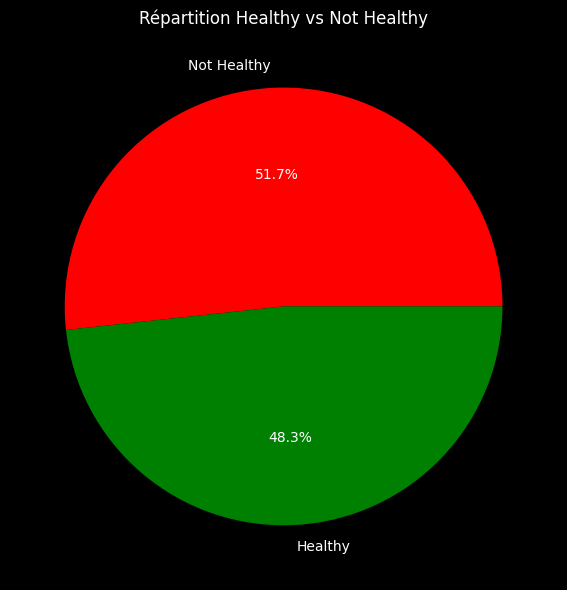

In [150]:
import matplotlib.pyplot as plt

labels = ['Not Healthy', 'Healthy']
values = gooddf_macro['is_healthy'].value_counts().sort_index().values
colors = ['red', 'green']

plt.figure(figsize=(6, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', textprops={'color': 'white'})
plt.title('Répartition Healthy vs Not Healthy', color='white')
plt.tight_layout()
plt.show()

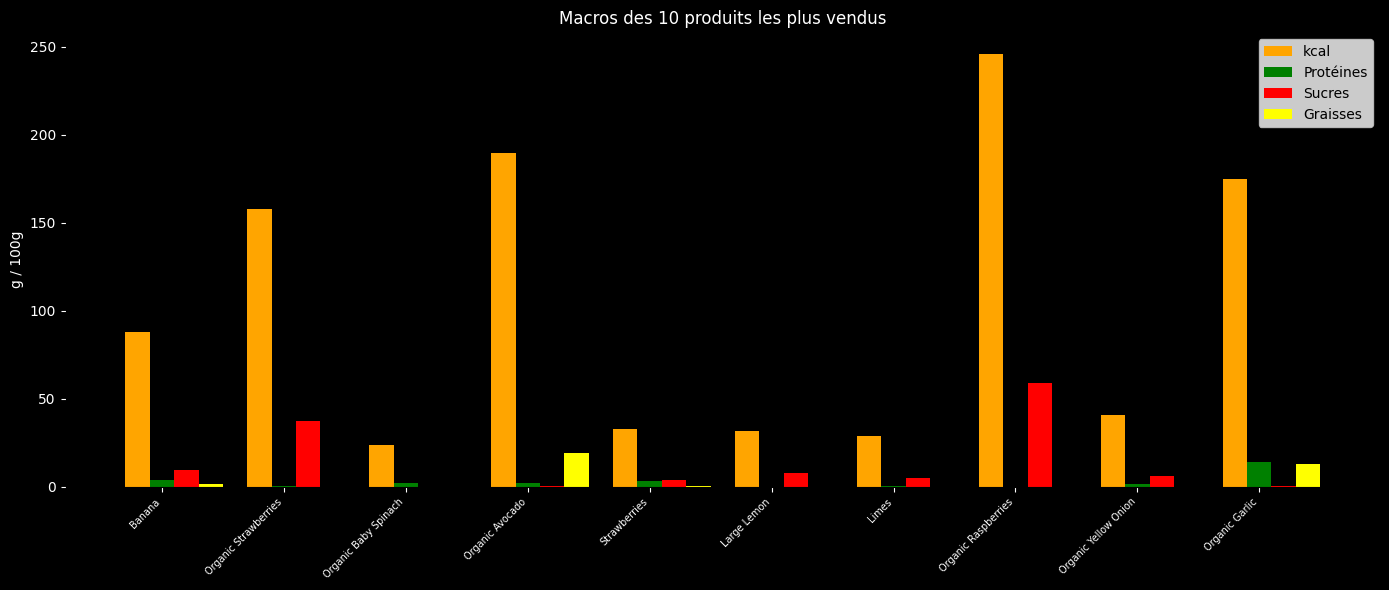

In [151]:
import numpy as np

top10 = gooddf_macro.dropna().head(10)
x = np.arange(len(top10))
width = 0.2

plt.figure(figsize=(14, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.bar(x - width, top10['energy-kcal_100g'], width, label='kcal', color='orange')
ax.bar(x, top10['proteins_100g'], width, label='Protéines', color='green')
ax.bar(x + width, top10['sugars_100g'], width, label='Sucres', color='red')
ax.bar(x + width*2, top10['fat_100g'], width, label='Graisses', color='yellow')
ax.set_xticks(x)
ax.set_xticklabels(top10['product_name'], rotation=45, ha='right', color='white', fontsize=7)
ax.set_title('Macros des 10 produits les plus vendus', color='white')
ax.set_ylabel('g / 100g', color='white')
ax.tick_params(colors='white')
ax.legend()
plt.tight_layout()
plt.show()

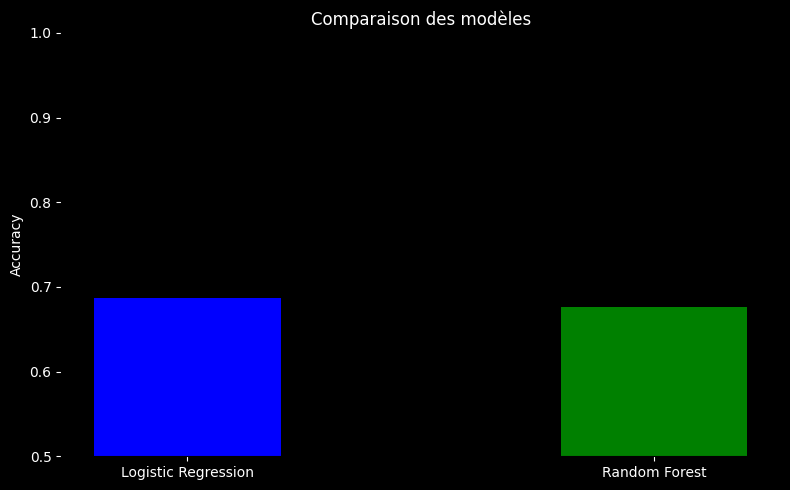

In [152]:
models = ['Logistic Regression', 'Random Forest']
scores = [accuracy_score(y_test, model1.predict(X_test)), 
          accuracy_score(y_test, model2.predict(X_test))]

plt.figure(figsize=(8, 5), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
plt.bar(models, scores, color=['blue', 'green'], width=0.4)
plt.title('Comparaison des modèles', color='white')
plt.ylabel('Accuracy', color='white')
plt.ylim(0.5, 1.0)
plt.tick_params(colors='white')
plt.tight_layout()
plt.show()